In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

from google.colab import files
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

Download the dataset

In [13]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00352/Online%20Retail.xlsx"
df = pd.read_excel(url)

df["Quantity"] = pd.to_numeric(df["Quantity"], errors="coerce")
df["UnitPrice"] = pd.to_numeric(df["UnitPrice"], errors="coerce")
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"], errors="coerce")

df = df.dropna(subset=["InvoiceNo", "StockCode", "InvoiceDate", "Quantity", "UnitPrice"])
df = df.drop_duplicates()
df = df[(df["Quantity"] > 0) & (df["UnitPrice"] > 0)]
df["TotalSales"] = df["Quantity"] * df["UnitPrice"]

print("Cleaned Dataset Shape:", df.shape)
display(df.head())

Cleaned Dataset Shape: (524878, 9)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalSales
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


Prepare monthly sales data

In [14]:
df["YearMonth"] = df["InvoiceDate"].dt.to_period("M")

monthly_sales = df.groupby("YearMonth").agg(
    TotalSales=("TotalSales", "sum"),
    TotalQuantity=("Quantity", "sum"),
    NumberOfInvoices=("InvoiceNo", "nunique")
).reset_index()

monthly_sales["YearMonth"] = monthly_sales["YearMonth"].astype(str)

print("Monthly Sales Data:")
display(monthly_sales.head())

print("\nNumber of months:", len(monthly_sales))

Monthly Sales Data:


,YearMonth,TotalSales,TotalQuantity,NumberOfInvoices
0,2010-12,821452.730,358019,1559
1,2011-01,689811.610,387099,1086
2,2011-02,522545.560,282934,1100
3,2011-03,716215.260,376599,1454
4,2011-04,536968.491,307953,1246



Number of months: 13


Visualize historical sales

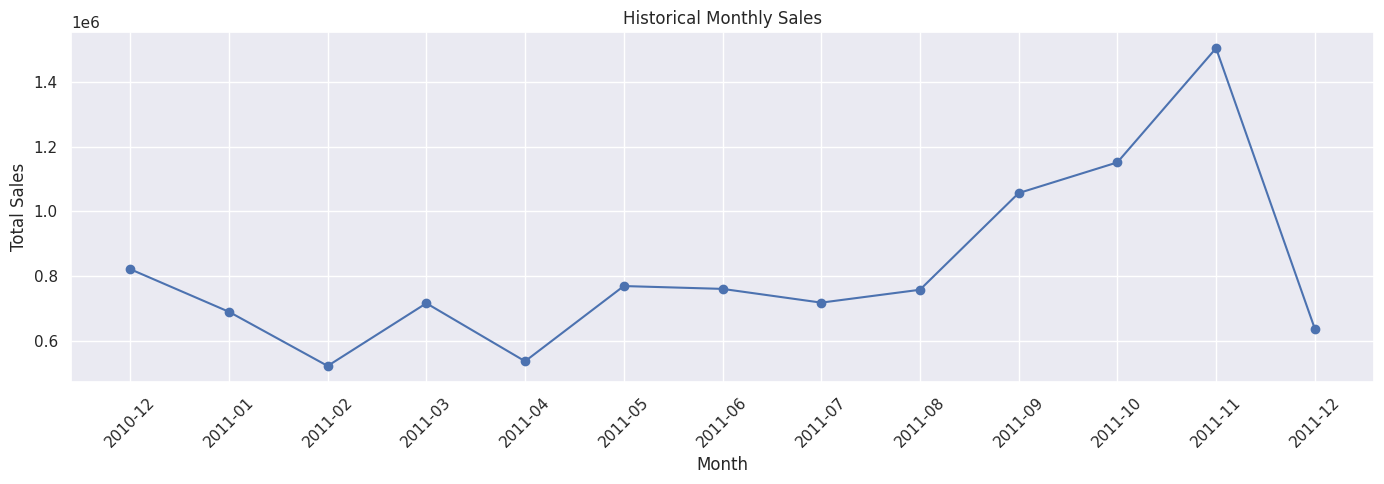

In [15]:
plt.figure(figsize=(14, 5))
plt.plot(monthly_sales["YearMonth"], monthly_sales["TotalSales"], marker="o")
plt.title("Historical Monthly Sales")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

Create time-based features

In [16]:
monthly_sales["TimeIndex"] = np.arange(len(monthly_sales))
monthly_sales["Month"] = pd.to_datetime(monthly_sales["YearMonth"]).dt.month
monthly_sales["Year"] = pd.to_datetime(monthly_sales["YearMonth"]).dt.year

display(monthly_sales.head())

,YearMonth,TotalSales,TotalQuantity,NumberOfInvoices,TimeIndex,Month,Year
0,2010-12,821452.730,358019,1559,0,12,2010
1,2011-01,689811.610,387099,1086,1,1,2011
2,2011-02,522545.560,282934,1100,2,2,2011
3,2011-03,716215.260,376599,1454,3,3,2011
4,2011-04,536968.491,307953,1246,4,4,2011


 Create training and testing data

In [17]:
split = int(len(monthly_sales) * 0.8)

train = monthly_sales.iloc[:split].copy()
test = monthly_sales.iloc[split:].copy()

features = ["TimeIndex", "Month", "Year"]

X_train = train[features]
y_train = train["TotalSales"]

X_test = test[features]
y_test = test["TotalSales"]

print("Training samples:", len(train))
print("Testing samples:", len(test))

Training samples: 10
Testing samples: 3


Train the predictive model

In [18]:
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Model training completed.")
print("Model Coefficients:", model.coef_)
print("Model Intercept:", model.intercept_)

Model training completed.
Model Coefficients: [ 2.66984799e+13 -2.66984799e+13 -3.20381759e+14]
Model Intercept: 6.442877175949134e+17


Calculate MAE and RMSE

In [19]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"Mean Absolute Error (MAE): £{mae:,.2f}")
print(f"Root Mean Squared Error (RMSE): £{rmse:,.2f}")

Mean Absolute Error (MAE): £377,321.39
Root Mean Squared Error (RMSE): £398,371.13


Actual vs Predicted Sales

,YearMonth,TotalSales,PredictedSales
10,2011-10,1151263.73,925312.0
11,2011-11,1503866.78,965376.0
12,2011-12,637790.33,1005312.0


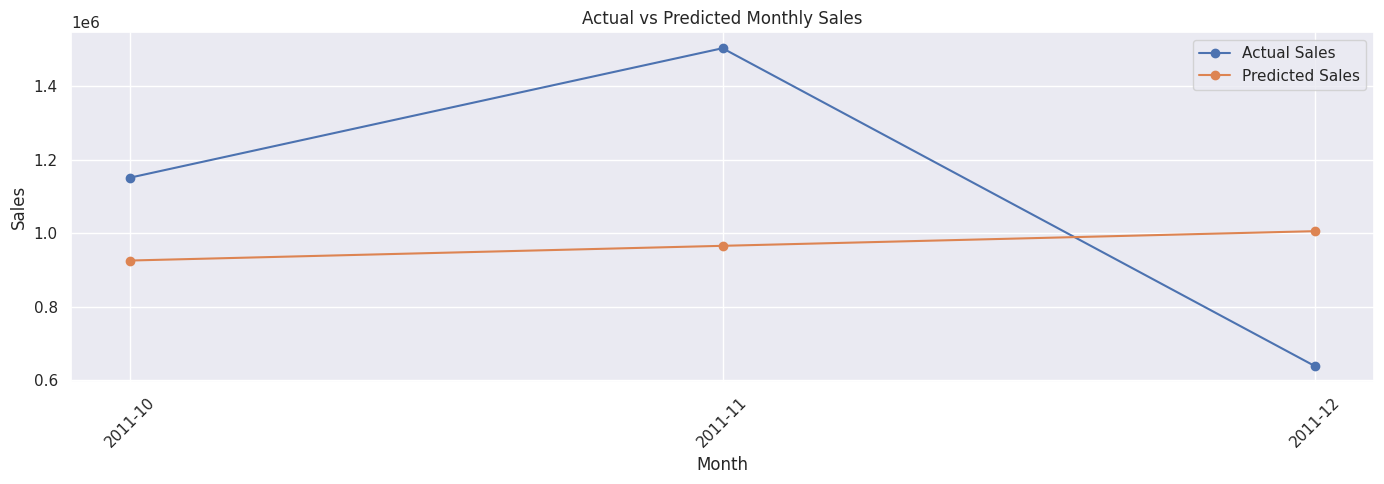

In [20]:
results = test[["YearMonth", "TotalSales"]].copy()
results["PredictedSales"] = y_pred

display(results)

plt.figure(figsize=(14, 5))
plt.plot(results["YearMonth"], results["TotalSales"], marker="o", label="Actual Sales")
plt.plot(results["YearMonth"], results["PredictedSales"], marker="o", label="Predicted Sales")
plt.title("Actual vs Predicted Monthly Sales")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Calculate prediction error percentage

In [21]:
results["AbsoluteError"] = abs(results["TotalSales"] - results["PredictedSales"])
results["ErrorPercentage"] = (
    results["AbsoluteError"] / results["TotalSales"] * 100
)

display(results)

print(f"Average Error Percentage: {results['ErrorPercentage'].mean():.2f}%")

,YearMonth,TotalSales,PredictedSales,AbsoluteError,ErrorPercentage
10,2011-10,1151263.73,925312.0,225951.73,19.626409
11,2011-11,1503866.78,965376.0,538490.78,35.807080
12,2011-12,637790.33,1005312.0,367521.67,57.624215


Average Error Percentage: 37.69%


Forecast next 3 months

In [22]:
last_index = monthly_sales["TimeIndex"].max()
last_date = pd.to_datetime(monthly_sales["YearMonth"].iloc[-1])

future_dates = pd.date_range(
    start=last_date + pd.offsets.MonthBegin(1),
    periods=3,
    freq="MS"
)

future = pd.DataFrame({
    "YearMonth": future_dates.strftime("%Y-%m"),
    "TimeIndex": range(last_index + 1, last_index + 4),
    "Month": future_dates.month,
    "Year": future_dates.year
})

future["PredictedSales"] = model.predict(future[features])

display(future)

,YearMonth,TimeIndex,Month,Year,PredictedSales
0,2012-01,13,1,2012,749184.0
1,2012-02,14,2,2012,789248.0
2,2012-03,15,3,2012,829184.0


Visualize future forecast

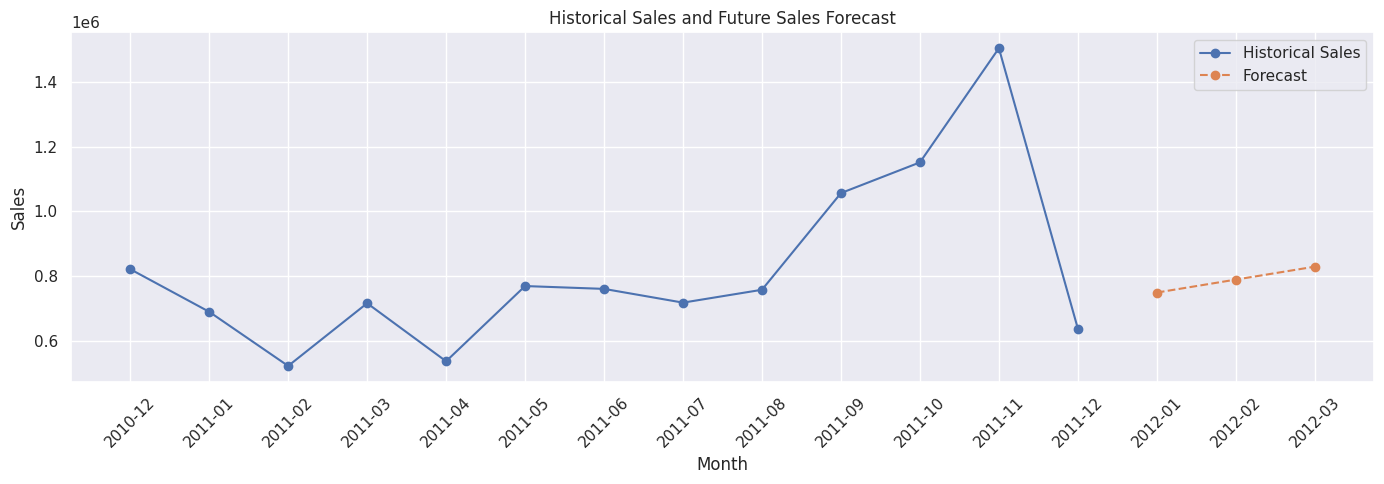

In [23]:
plt.figure(figsize=(14, 5))

plt.plot(
    monthly_sales["YearMonth"],
    monthly_sales["TotalSales"],
    marker="o",
    label="Historical Sales"
)

plt.plot(
    future["YearMonth"],
    future["PredictedSales"],
    marker="o",
    linestyle="--",
    label="Forecast"
)

plt.title("Historical Sales and Future Sales Forecast")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [24]:
os.makedirs("week3_output", exist_ok=True)

monthly_sales.to_csv(
    "week3_output/monthly_sales.csv",
    index=False
)

results.to_csv(
    "week3_output/actual_vs_predicted.csv",
    index=False
)

future.to_csv(
    "week3_output/future_forecast.csv",
    index=False
)

print("Week 3 files saved successfully.")

Week 3 files saved successfully.
